# Basketball Player Detection and Annotation

This notebook detects basketball players and balls in images using a local YOLOv8 model and visualizes results with Supervision.

In [8]:
!nvidia-smi

Mon Mar 16 10:08:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q gdown inference-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 4.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 

In [ ]:
!pip list | grep supervision

In [ ]:
import os
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

In [ ]:
# Google Drive bootstrap + project paths
from pathlib import Path
import sys, subprocess

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Change this if your repo folder name is different in Drive
REPO_ROOT = Path('/content/drive/MyDrive/basketball-ai-collection')

# Install project dependencies into current notebook kernel
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(REPO_ROOT / 'requirements.txt')])

# Required variables
MODEL_FILE_PATH = REPO_ROOT / 'models' / 'best.pt'
SOURCE_IMAGE_PATH = REPO_ROOT / 'input' / 'v_-6Os86HzwCs_c001' / 'img1' / '000281.jpg'

# Other paths used later in notebook
MODEL_PATH = MODEL_FILE_PATH
SOURCE_IMAGES_PATH = REPO_ROOT / 'input' / 'v_-6Os86HzwCs_c001' / 'img1'
SEQINFO_PATH = REPO_ROOT / 'input' / 'v_-6Os86HzwCs_c001' / 'seqinfo.ini'
TARGET_VIDEO_PATH = REPO_ROOT / 'output' / 'v_-6Os86HzwCs_c001_result.mp4'
TARGET_TRACKER_VIDEO_PATH = REPO_ROOT / 'output' / 'v_-6Os86HzwCs_c001_tracker-result.mp4'

print('MODEL_FILE_PATH exists:', MODEL_FILE_PATH.exists(), '->', MODEL_FILE_PATH)
print('SOURCE_IMAGE_PATH exists:', SOURCE_IMAGE_PATH.exists(), '->', SOURCE_IMAGE_PATH)

FileNotFoundError: Repository not found in runtime. Set GITHUB_REPO_URL env var or update REPO_DIR_NAME / path candidates.

## Section 1: Load Model from best.pt

Load the YOLOv8 trained model from a local best.pt file.

In [ ]:
from ultralytics import YOLO
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

if not MODEL_FILE_PATH.exists():
    raise FileNotFoundError(f'Model not found at: {MODEL_FILE_PATH}')

PLAYER_DETECTION_MODEL = YOLO(str(MODEL_FILE_PATH))
print(f'✓ Model loaded from {MODEL_FILE_PATH}')

ModuleNotFoundError: No module named 'ultralytics'

## Section 2: Import Libraries

Import OpenCV and Supervision for image processing and detection visualization.

In [5]:
import supervision as sv
import cv2

## Section 3: Configure Image Path and Class IDs

Load the source image and define class IDs for detection.

In [ ]:
BALL_ID = 0
PLAYER_ID = 3

frame = cv2.imread(str(SOURCE_IMAGE_PATH))
if frame is None:
    raise FileNotFoundError(f'Could not read image: {SOURCE_IMAGE_PATH}')

## Section 4: Setup Annotators

Configure annotators for visualization with custom colors and styling.

In [7]:
ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2
)

triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex('#FFD700'),
    base=25,
    height=21,
    outline_thickness=1
)

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(
        ['#00BFFF', '#FF1493', '#FFD700']
    ),
    thickness=2
)

label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(
        ['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']
    ),
    text_color=sv.Color.from_hex('#000000')
)

## Section 5: Run Object Detection

Execute inference on the frame using the YOLOv8 model.

In [ ]:
# Run inference using the YOLOv8 model
results = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3, device=DEVICE)[0]

# Convert YOLOv8 results to Supervision detections
detections = sv.Detections.from_ultralytics(results)


0: 736x1280 1 Hoop, 10 Players, 1 Ref, 3 Team Pointss, 2 Time Remainings, 1812.0ms
Speed: 6.5ms preprocess, 1812.0ms inference, 8.4ms postprocess per image at shape (1, 3, 736, 1280)


## Section 6: Filter and Process Detections

Filter player and ball detections by class ID. Apply NMS (Non-Maximum Suppression) to player detections and pad ball detection boxes.

In [53]:
player_detections = detections[detections.class_id == PLAYER_ID]
player_detections = player_detections.with_nms(
    threshold=0.5,
    class_agnostic=True
)

ball_detections = detections[detections.class_id == BALL_ID]
ball_detections.xyxy = sv.pad_boxes(
    xyxy=ball_detections.xyxy,
    px=10
)

## Section 7: Annotate and Visualize Results

Annotate the frame with player bounding boxes and ball markers, then display the results.

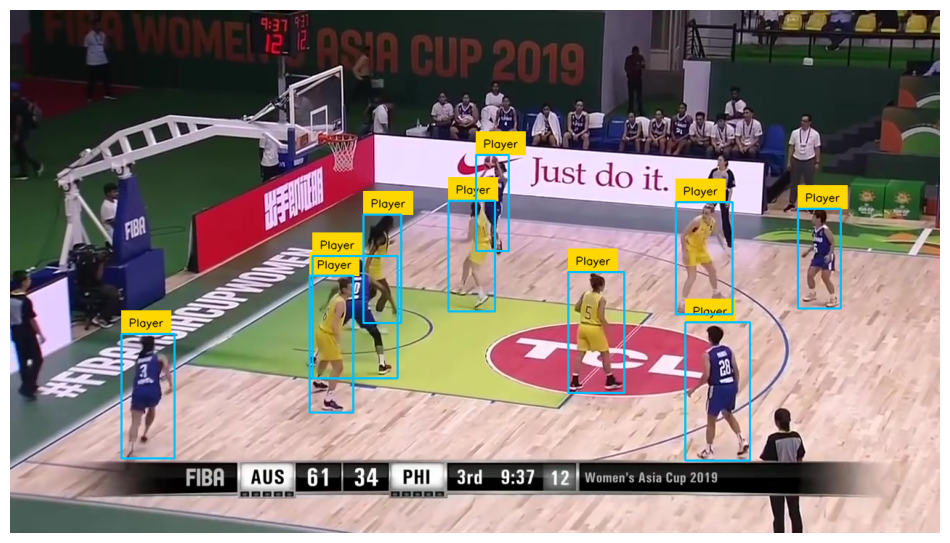

In [55]:
annotated_frame = frame.copy()
annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=player_detections)
annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=player_detections)
annotated_frame = triangle_annotator.annotate(scene=annotated_frame, detections=ball_detections)

sv.plot_image(annotated_frame)

## Section 8: Batch Processing - Read Video Sequence and Write Detection Results

Read image sequence from input folder, perform player detection, and save annotated video to output folder.

In [ ]:
from tqdm import tqdm
from configparser import ConfigParser

# Read sequence info
config = ConfigParser()
config.read(str(SEQINFO_PATH))
fps = int(config['Sequence']['frameRate'])
width = int(config['Sequence']['imWidth'])
height = int(config['Sequence']['imHeight'])

# Get image files
image_files = sorted(SOURCE_IMAGES_PATH.glob('*.jpg'))
print(f'Found {len(image_files)} images in {SOURCE_IMAGES_PATH}')

# Create output directory
TARGET_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)

Found 825 images in ../input/v_-6Os86HzwCs_c001/img1


In [ ]:
# Process frames
video_sink = sv.VideoSink(str(TARGET_VIDEO_PATH), video_info=sv.VideoInfo(width=width, height=height, fps=fps, total_frames=len(image_files)))

with video_sink:
    for img_path in tqdm(image_files):
        frame = cv2.imread(str(img_path))
        results = PLAYER_DETECTION_MODEL.predict(frame, conf=0.3, device=DEVICE)[0]
        detections = sv.Detections.from_ultralytics(results)
        labels = [f"{results.names[int(cls_id)]} {conf:.2f}" for cls_id, conf in zip(detections.class_id, detections.confidence)]
        annotated_frame = box_annotator.annotate(frame.copy(), detections=detections)
        annotated_frame = label_annotator.annotate(annotated_frame, detections=detections, labels=labels)
        video_sink.write_frame(annotated_frame)

print(f'✓ Video saved to {TARGET_VIDEO_PATH}')

Found 825 images in ../input/v_-6Os86HzwCs_c001/img1


  0%|          | 0/825 [00:00<?, ?it/s]

## Section 9: Player Tracking with ByteTrack

Run player tracking across the video sequence using the PlayerTracker class to maintain consistent player identities across frames. Process frames and generate an annotated output video with tracked player IDs.

In [ ]:
import sys
sys.path.append(str(REPO_ROOT))
from trackers.player_tracker import PlayerTracker

# Initialize the PlayerTracker with the same model
tracker = PlayerTracker(str(MODEL_PATH))

# Read all frames from the image sequence
image_files = sorted(SOURCE_IMAGES_PATH.glob('*.jpg'))
frames = [cv2.imread(str(img_path)) for img_path in image_files]

# Get player tracks with tracking
stub_path = str(REPO_ROOT / 'stubs' / 'player_tracks.pkl')
(REPO_ROOT / 'stubs').mkdir(parents=True, exist_ok=True)
player_tracks = tracker.get_object_tracks(frames, read_from_stub=False, stub_path=stub_path)

# Create output video with tracked players
video_sink = sv.VideoSink(str(TARGET_TRACKER_VIDEO_PATH), video_info=sv.VideoInfo(width=width, height=height, fps=fps, total_frames=len(frames)))

with video_sink:
    for frame_idx, frame in enumerate(tqdm(frames)):
        annotated_frame = frame.copy()
        
        # Get tracks for this frame
        frame_tracks = player_tracks[frame_idx]
        
        # Annotate each tracked player
        for track_id, track_info in frame_tracks.items():
            bbox = track_info['bbox']
            # Draw bounding box
            x1, y1, x2, y2 = [int(coord) for coord in bbox]
            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Draw track ID label
            cv2.putText(annotated_frame, f'ID: {int(track_id)}', (x1, y1 - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        video_sink.write_frame(annotated_frame)

print(f'✓ Tracking video saved to {TARGET_TRACKER_VIDEO_PATH}')
print(f'✓ Processed {len(frames)} frames with player tracking.')